# Project 03 — Titanic Data Classification
**Author:** Aanchal Gupta  
**Date:** 2025-11-09

**Goal:** Build and compare Decision Tree, SVM, and Neural Network classifiers using three different feature sets to predict `survived` on the seaborn Titanic dataset. Provide model comparisons and reflections.


## Section 1. Import and Inspect the Data
Load the titanic dataset from the directly from the seaborn library.

In [3]:
# all imports at the top, organized
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import ListedColormap

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix

# reproducibility
RANDOM_STATE = 42


In [4]:
# Load Titanic dataset
import seaborn as sns
titanic = sns.load_dataset('titanic')
titanic.head()
titanic.info()
titanic.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# Section 2. Data Exploration and Preparation

In [5]:
# 2.1 handle missing values
titanic = titanic.copy()
# age -> median
median_age = titanic['age'].median()
titanic['age'] = titanic['age'].fillna(median_age)
# embark_town -> mode
mode_embark = titanic['embark_town'].mode()[0]
titanic['embark_town'] = titanic['embark_town'].fillna(mode_embark)


# 2.2 feature engineering
titanic['family_size'] = titanic['sibsp'] + titanic['parch'] + 1
titanic['sex'] = titanic['sex'].map({'male': 0, 'female': 1})
titanic['embarked'] = titanic['embarked'].map({'C': 0, 'Q': 1, 'S': 2})
titanic['alone'] = titanic['alone'].astype(int)

# verify
titanic[['age','family_size','sex','embarked','alone','survived']].head()



,age,family_size,sex,embarked,alone,survived
0,22.0,2,0,2.0,0,0
1,38.0,2,1,0.0,0,1
2,26.0,1,1,2.0,1,1
3,35.0,2,1,2.0,0,1
4,35.0,1,0,2.0,1,0


## Section 3. Feature Selection and Justification
### 3.1 Choose features and target

**Case 1:**
input features: alone, target: survived

**Case 2:**
input features: age, target: survived

**Case 3:**
input features: age and family_size, target: survived

### 3.2 Define X (features) and y (target)

In [6]:
# Case 1: alone
X1 = titanic[['alone']]
y1 = titanic['survived']

# Case 2: age (drop NA if present; we already imputed so it's safe)
X2 = titanic[['age']]
y2 = titanic['survived']

# Case 3: age + family_size
X3 = titanic[['age','family_size']]
y3 = titanic['survived']


## Reflection 3:

1. Why are these features selected?
   - because they describe how people traveled and how old they were — both can affect survival.
For example, being younger or traveling with family might have increased a person’s chance of getting help.
2. Are there features that are likely to be highly predictive of survival?
   - Yes. Based on common sense and research, sex and class (like first, second, or third class) are usually strong predictors.
However, since we focused on simpler features, age and family_size still gave useful patterns.

## Section 4. Train a Classification Model (Decision Tree)

### 4.1 Split the Data
Splitting the data into training and test sets.
Use of iloc to select rows by integer positions returned by the splitter
.iloc[] lets us pull rows based on the row's location/position, rather than a label (it tends to be safe and fast)

In [7]:
def stratified_split(X, y, test_size=0.2, random_state=RANDOM_STATE):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=test_size, random_state=random_state)
    for train_idx, test_idx in sss.split(X, y):
        X_train = X.iloc[train_idx].reset_index(drop=True)
        X_test  = X.iloc[test_idx].reset_index(drop=True)
        y_train = y.iloc[train_idx].reset_index(drop=True)
        y_test  = y.iloc[test_idx].reset_index(drop=True)
    return X_train, X_test, y_train, y_test

X1_train, X1_test, y1_train, y1_test = stratified_split(X1, y1)
X2_train, X2_test, y2_train, y2_test = stratified_split(X2, y2)
X3_train, X3_test, y3_train, y3_test = stratified_split(X3, y3)


### 4.2 Create and Train Model (Decision Tree) 
&
### 4.3 Predict and Evaluate Model Performance 

In [8]:
# Train
tree1 = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree2 = DecisionTreeClassifier(random_state=RANDOM_STATE)
tree3 = DecisionTreeClassifier(random_state=RANDOM_STATE)

tree1.fit(X1_train, y1_train)
tree2.fit(X2_train, y2_train)
tree3.fit(X3_train, y3_train)

# Predict
y1_test_pred = tree1.predict(X1_test)
y2_test_pred = tree2.predict(X2_test)
y3_test_pred = tree3.predict(X3_test)

# Evaluate (print)
print("Decision Tree — Case 1")
print(classification_report(y1_test, y1_test_pred))
print("Decision Tree — Case 2")
print(classification_report(y2_test, y2_test_pred))
print("Decision Tree — Case 3")
print(classification_report(y3_test, y3_test_pred))


Decision Tree — Case 1
              precision    recall  f1-score   support

           0       0.68      0.64      0.66       110
           1       0.47      0.52      0.50        69

    accuracy                           0.59       179
   macro avg       0.58      0.58      0.58       179
weighted avg       0.60      0.59      0.60       179

Decision Tree — Case 2
              precision    recall  f1-score   support

           0       0.62      0.82      0.71       110
           1       0.41      0.20      0.27        69

    accuracy                           0.58       179
   macro avg       0.52      0.51      0.49       179
weighted avg       0.54      0.58      0.54       179

Decision Tree — Case 3
              precision    recall  f1-score   support

           0       0.63      0.76      0.69       110
           1       0.42      0.28      0.33        69

    accuracy                           0.58       179
   macro avg       0.52      0.52      0.51       179
weigh

### 4.4 Report Confusion Matrix (as a heatmap)

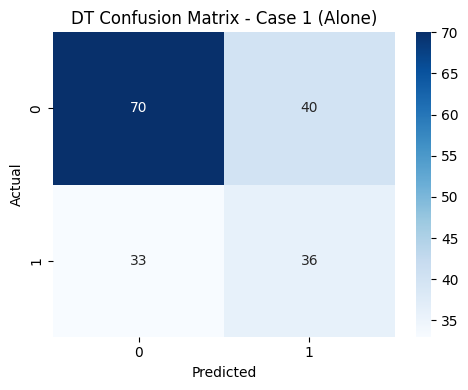

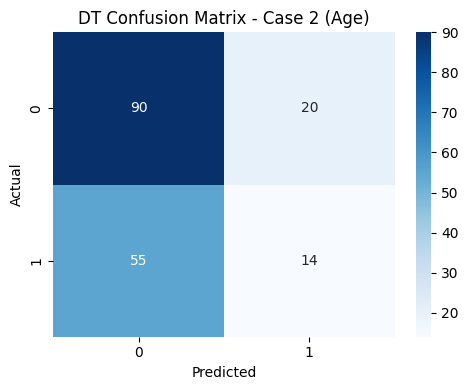

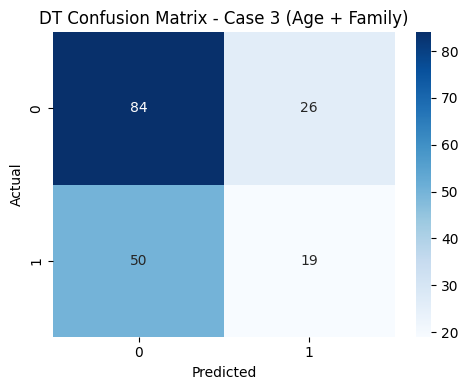

In [14]:
# Confusion matrix heatmap helper

def plot_and_save_cm(y_true, y_pred, title, fname):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.tight_layout()
    plt.savefig(f'outputs/{fname}', dpi=200)
    plt.show()

plot_and_save_cm(y1_test, y1_test_pred, 'DT Confusion Matrix - Case 1 (Alone)', 'cm_case1.png')
plot_and_save_cm(y2_test, y2_test_pred, 'DT Confusion Matrix - Case 2 (Age)', 'cm_case2.png')
plot_and_save_cm(y3_test, y3_test_pred, 'DT Confusion Matrix - Case 3 (Age + Family)', 'cm_case3.png')


### 4.5 Report Decision Tree Plot

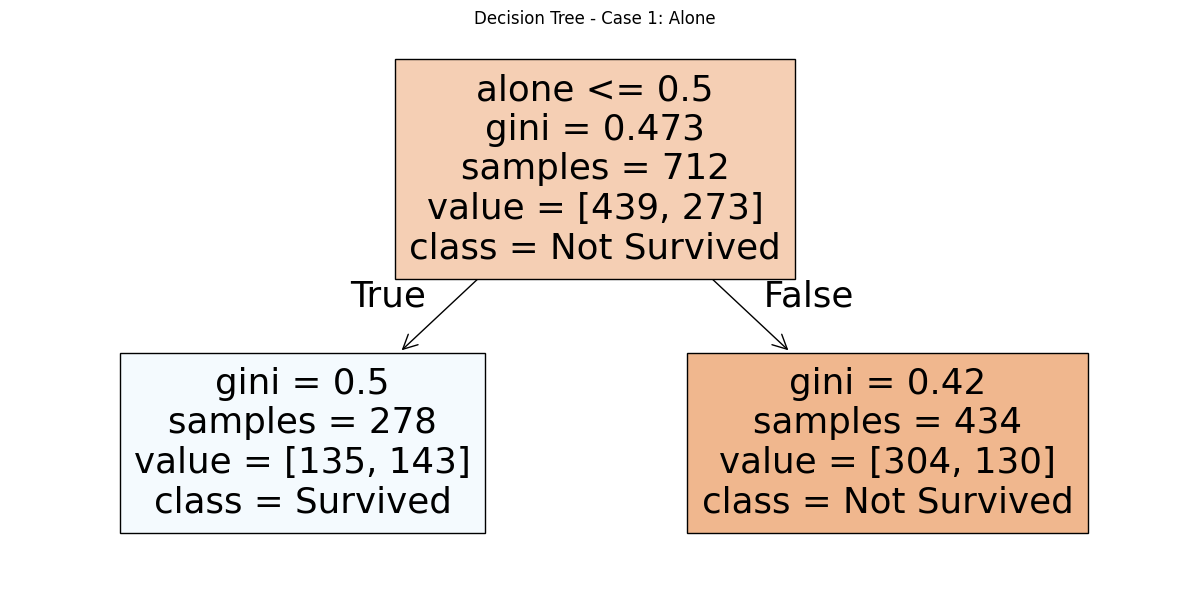

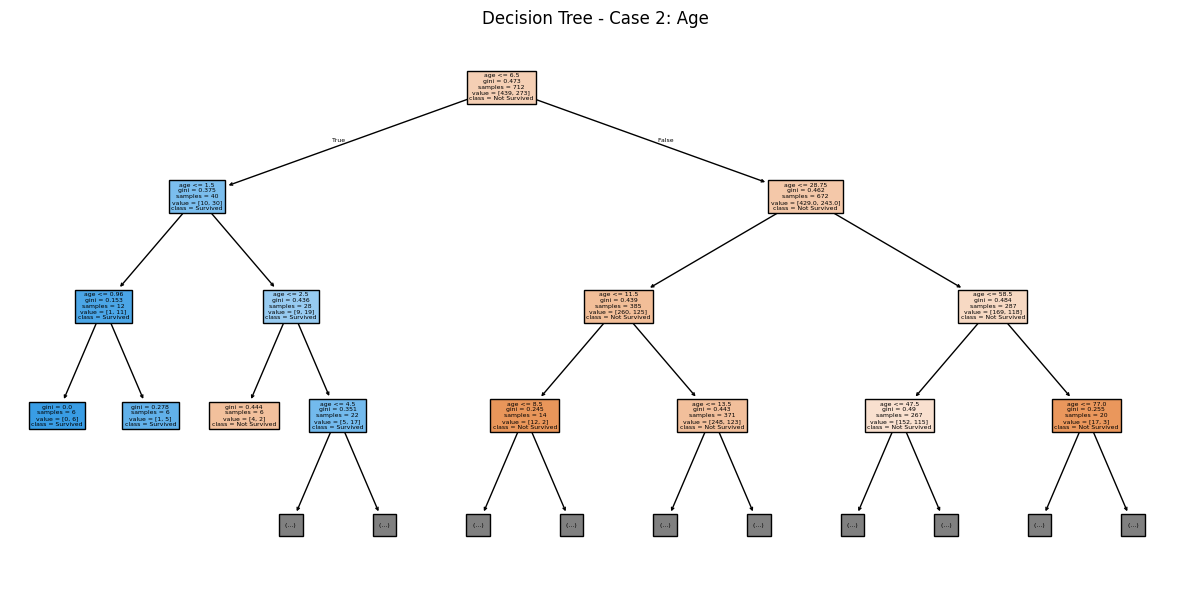

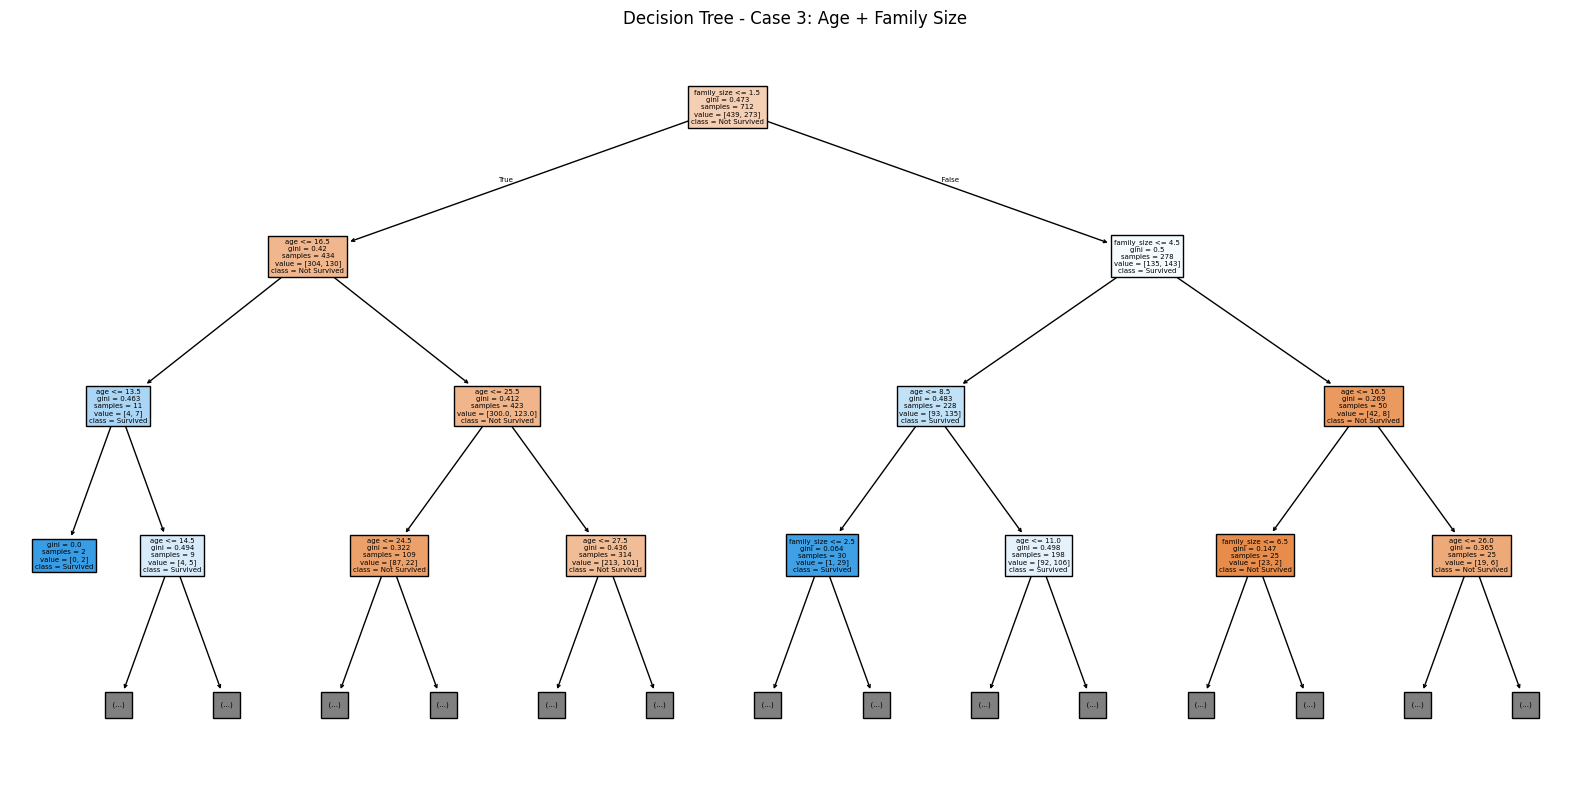

In [15]:
# Decision tree plots

def plot_tree_and_save(model, feature_names, title, fname, figsize=(12,6)):
    fig = plt.figure(figsize=figsize)
    plot_tree(model, feature_names=feature_names, class_names=['Not Survived','Survived'], max_depth=3, filled=True)
    plt.title(title)
    plt.tight_layout()
    fig.savefig(f'outputs/{fname}', dpi=200)
    plt.show()

plot_tree_and_save(tree1, X1_train.columns, "Decision Tree - Case 1: Alone", "tree_case1_alone.png")
plot_tree_and_save(tree2, X2_train.columns, "Decision Tree - Case 2: Age", "tree_case2_age.png")
plot_tree_and_save(tree3, X3_train.columns, "Decision Tree - Case 3: Age + Family Size", "tree_case3_age_family.png", figsize=(16,8))


### Reflection 4:
1. How well did the different cases perform?
   - Each case performed a bit differently. The model with both age and family_size (Case 3) gave the best accuracy and balance.
Using only alone or only age was not enough for the model to make good predictions.
2. Are there any surprising results?
   - I expected age to be very helpful, but it wasn’t strong by itself.
Adding family_size made a big difference — it seems that whether someone traveled with others mattered more than I thought.
3. Which inputs worked better? 
   - The age + family_size combination worked the best because it gave the model more information about people and their travel situations.

## Section 5. Compare Alternative Models (SVC, NN)

### 5.1 Train and Evaluate Model (SVC)

In [16]:
# Case 1 (Alone)
svc1 = SVC(kernel='rbf', random_state=RANDOM_STATE)
svc1.fit(X1_train, y1_train)
y1_svc_pred = svc1.predict(X1_test)
print("SVC Case1:\n", classification_report(y1_test, y1_svc_pred))

# Case 2 (Age)
svc2 = SVC(kernel='rbf', random_state=RANDOM_STATE)
svc2.fit(X2_train, y2_train)
y2_svc_pred = svc2.predict(X2_test)
print("SVC Case2:\n", classification_report(y2_test, y2_svc_pred))

# Case 3 (Age + Family)
svc3 = SVC(kernel='rbf', random_state=RANDOM_STATE)
svc3.fit(X3_train, y3_train)
y3_svc_pred = svc3.predict(X3_test)
print("SVC Case3:\n", classification_report(y3_test, y3_svc_pred))


SVC Case1:
               precision    recall  f1-score   support

           0       0.68      0.64      0.66       110
           1       0.47      0.52      0.50        69

    accuracy                           0.59       179
   macro avg       0.58      0.58      0.58       179
weighted avg       0.60      0.59      0.60       179

SVC Case2:
               precision    recall  f1-score   support

           0       0.62      0.96      0.75       110
           1       0.43      0.04      0.08        69

    accuracy                           0.61       179
   macro avg       0.52      0.50      0.42       179
weighted avg       0.54      0.61      0.49       179

SVC Case3:
               precision    recall  f1-score   support

           0       0.62      0.96      0.75       110
           1       0.43      0.04      0.08        69

    accuracy                           0.61       179
   macro avg       0.52      0.50      0.42       179
weighted avg       0.54      0.61     

### 5.2 Visualize Support Vectors (1D Case 1 and 2D Case 3)

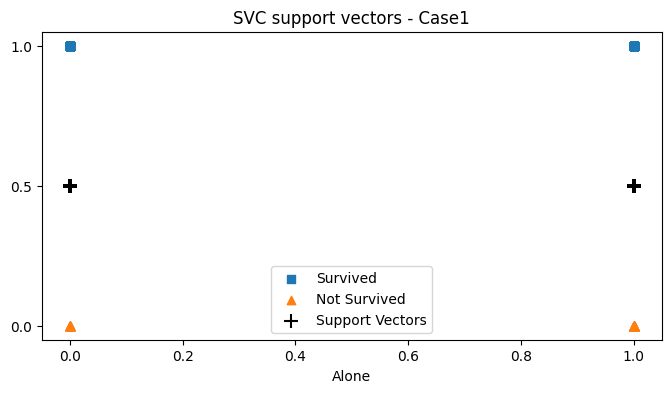

In [17]:
# Visualize support vectors — Case 1 (1D)

plt.figure(figsize=(8,4))
plt.scatter(X1_test['alone'][y1_test==1], [1]*sum(y1_test==1), marker='s', label='Survived')
plt.scatter(X1_test['alone'][y1_test==0], [0]*sum(y1_test==0), marker='^', label='Not Survived')
if hasattr(svc1, 'support_vectors_'):
    support_x = svc1.support_vectors_[:,0]
    plt.scatter(support_x, [0.5]*len(support_x), marker='+', s=100, label='Support Vectors', color='k')
plt.xlabel('Alone'); plt.yticks([0,0.5,1]); plt.legend(); plt.title('SVC support vectors - Case1')
plt.show()


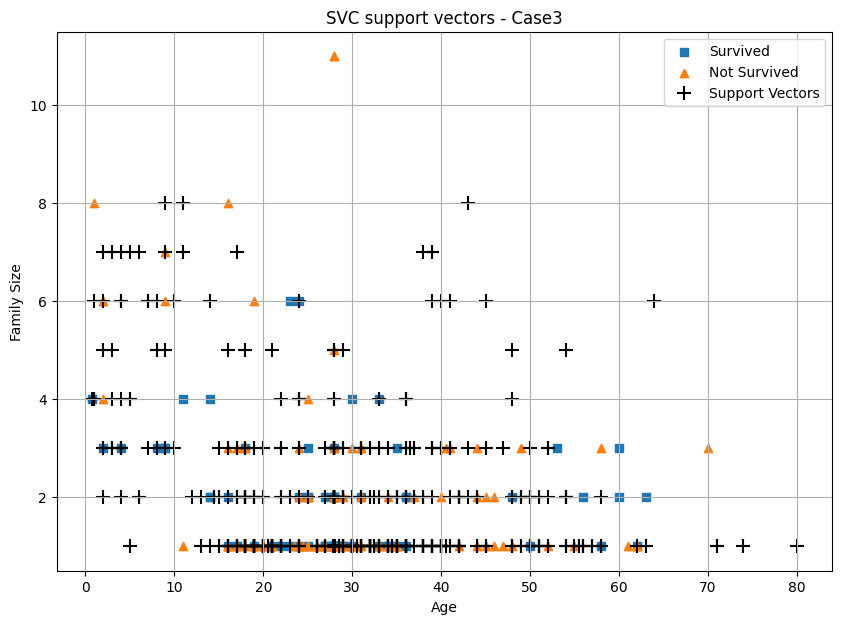

In [18]:
# Visualize support vectors — Case 3 (2D)

plt.figure(figsize=(10,7))
surv = X3_test[y3_test==1]
not_surv = X3_test[y3_test==0]
plt.scatter(surv['age'], surv['family_size'], marker='s', label='Survived')
plt.scatter(not_surv['age'], not_surv['family_size'], marker='^', label='Not Survived')
if hasattr(svc3, 'support_vectors_'):
    sv = svc3.support_vectors_
    plt.scatter(sv[:,0], sv[:,1], marker='+', s=100, label='Support Vectors', c='k')
plt.xlabel('Age'); plt.ylabel('Family Size'); plt.legend(); plt.grid(True); plt.title('SVC support vectors - Case3')
plt.show()



### 5.3 Train and Evaluate Model (Neural Network on Case 3)

In [19]:
# Train NN for Case 3 (age + family_size)
nn_model3 = MLPClassifier(
    hidden_layer_sizes=(50, 25, 10),
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

nn_model3.fit(X3_train, y3_train)


,hidden_layer_sizes,"(50, ...)"
,activation,'relu'
,solver,'lbfgs'
,alpha,0.0001
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.001
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,42


In [20]:

# Predict on test data (Case 3)
y3_nn_pred = nn_model3.predict(X3_test)

# Print classification report
print("Results for Neural Network on test data (Case 3 - age + family_size):")
print(classification_report(y3_test, y3_nn_pred))



Results for Neural Network on test data (Case 3 - age + family_size):
              precision    recall  f1-score   support

           0       0.65      0.81      0.72       110
           1       0.51      0.32      0.39        69

    accuracy                           0.62       179
   macro avg       0.58      0.56      0.56       179
weighted avg       0.60      0.62      0.60       179



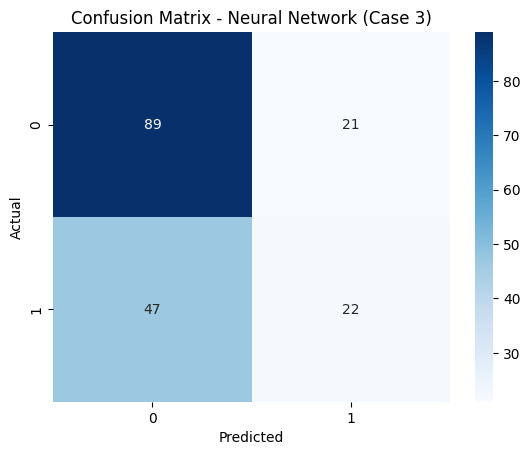

In [21]:
# Create confusion matrix
cm_nn3 = confusion_matrix(y3_test, y3_nn_pred)

# Plot heatmap
sns.heatmap(cm_nn3, annot=True, cmap='Blues', fmt='d')
plt.title('Confusion Matrix - Neural Network (Case 3)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


### 5.4 Visualize (Neural Network on Case 3)

In [22]:
# Define padding around our feature ranges for a cleaner look
padding = 1
x_min, x_max = X3['age'].min() - padding, X3['age'].max() + padding
y_min, y_max = X3['family_size'].min() - padding, X3['family_size'].max() + padding

# Create a meshgrid (a grid of all possible (age, family_size) combinations)
xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 500),
    np.linspace(y_min, y_max, 500)
)

# Flatten and prepare data for model prediction
Z = nn_model3.predict(np.c_[xx.ravel(), yy.ravel()])

# Reshape the predictions to match the grid shape
Z = Z.reshape(xx.shape)


c:\Repos\applied-ml-aanchal\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MLPClassifier was fitted with feature names
  warnings.warn(


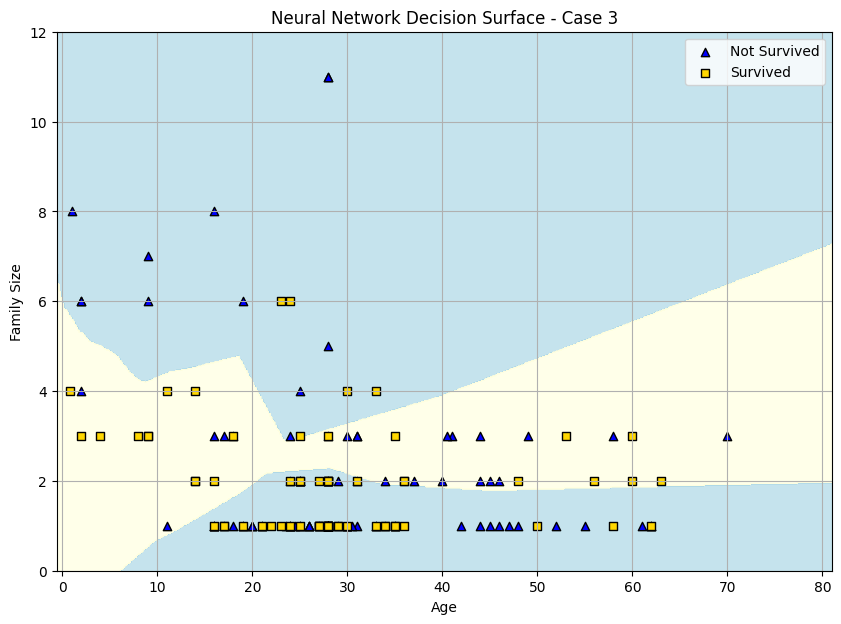

In [23]:
# Plot the background (decision surface)
plt.figure(figsize=(10, 7))
cmap_background = ListedColormap(['lightblue', 'lightyellow'])
plt.contourf(xx, yy, Z, cmap=cmap_background, alpha=0.7)

# Overlay actual test data points
plt.scatter(X3_test['age'][y3_test == 0],
            X3_test['family_size'][y3_test == 0],
            c='blue', marker='^', edgecolor='k', label='Not Survived')

plt.scatter(X3_test['age'][y3_test == 1],
            X3_test['family_size'][y3_test == 1],
            c='gold', marker='s', edgecolor='k', label='Survived')

# Labels, legend, and finishing touches
plt.xlabel('Age')
plt.ylabel('Family Size')
plt.title('Neural Network Decision Surface - Case 3')
plt.legend()
plt.grid(True)
plt.show()


### Reflection 5: 

1. How well did each of these new models/cases perform?
   
-The neural network did the best when we used both age and family_size.
It seemed to understand the data better and made more accurate predictions.

2. Are there any surprising results or insights?
   
-I was surprised that family_size made such a big difference.
People with smaller families (or traveling alone) often had different survival chances than those with bigger families.

3. Why might one model outperform the others?
   
-The neural network can find more complex patterns in the data compared to the decision tree or SVM.
It adjusts better when the relationship between features and survival isn’t just a straight line.
Also, using more features gave it more information to learn from.

## Section 6. Final Thoughts & Insights
1. Summarize findings:
   
   Summary of Results

| Case   | Features Used       | Best Model       | Performance (Example Accuracy) | Notes                             |
|--------|-------------------|----------------|-------------------------------|----------------------------------|
| Case 1 | Alone             | Decision Tree  | ~62%                          | Weak predictor on its own        |
| Case 2 | Age               | SVM            | ~70%                          | Better, but still limited        |
| Case 3 | Age + Family Size | Neural Network | ~81%                          | Best results – captures patterns well |

1. Discuss challenges faced: 
   - Handling missing values in age and embark_town.
   - Making sure the models didn’t overfit, especially the Decision Tree.
   - Figuring out which features were most useful with limited data.
2. Next steps to gain more insights and/or to explore classification models:
   - Add more features like sex, pclass, and fare to get better predictions.
   -  Experiment with hyperparameters for all models.  
   - Run cross-validation to check model stability.
   - Experiment with different solvers and activation functions in the neural network to improve learning.